# For a galaxy, plot the predictions from the november runs vs. the december runs


with stellar priors

In [5]:
import numpy as np
import dill as pickle
import matplotlib
import corner
from matplotlib import pyplot as plt
from pkg_resources import resource_filename
import cue
from cue.line import predict
from cue.utils import (c, cont_lam, new_sorted_line_name, 
                       logQ, Qtotal,
                       get_loglinear_spectra, ionparam2norm, calcQ) # this includes some constants and functions for the fits and output plots

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


In [7]:
# define line labels of the emission lines for the plots
round_to_n = lambda x, n: x if x == 0 else round(x, -int(np.floor(np.log10(abs(x)))) + (n - 1))
def formatNumber(num):
    if num % 1 == 0:
        return str(int(num))
    else:
        return str(num)
    
shortened_sorted_line_name = list()
for i in range(len(new_sorted_line_name)):
    new_name = new_sorted_line_name[i][:5] + \
    formatNumber(round_to_n(float(new_sorted_line_name[i][5:12]), 4)) + \
    new_sorted_line_name[i][12]
    if new_name[-1] == 'A':
        new_name = new_name[:-1] #+ r'$\mathrm{\AA}$'
    if new_name[-1] == 'm':
        new_name = new_name[:-1] #+ r'$\mathrm{\mu}$m'
    shortened_sorted_line_name.append(new_name)
shortened_sorted_line_name = np.array(shortened_sorted_line_name)

In [9]:
galaxynames = ["BX216", "BX274", "BX336", "BX341", "BX348", "BX350", "BX390", "BX418", "BX429", "BX461", "BX474", "BX523", "BX587", "BX628", "D40", "fBM40", "fBM47", "fC23"] 

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'H  1 9014.91A' 'H  1 9229.02A'
 'He 1 7065.25A' 'O  2 7323.00A' 'O  2 7332.00A' 'S  3 9068.62A']


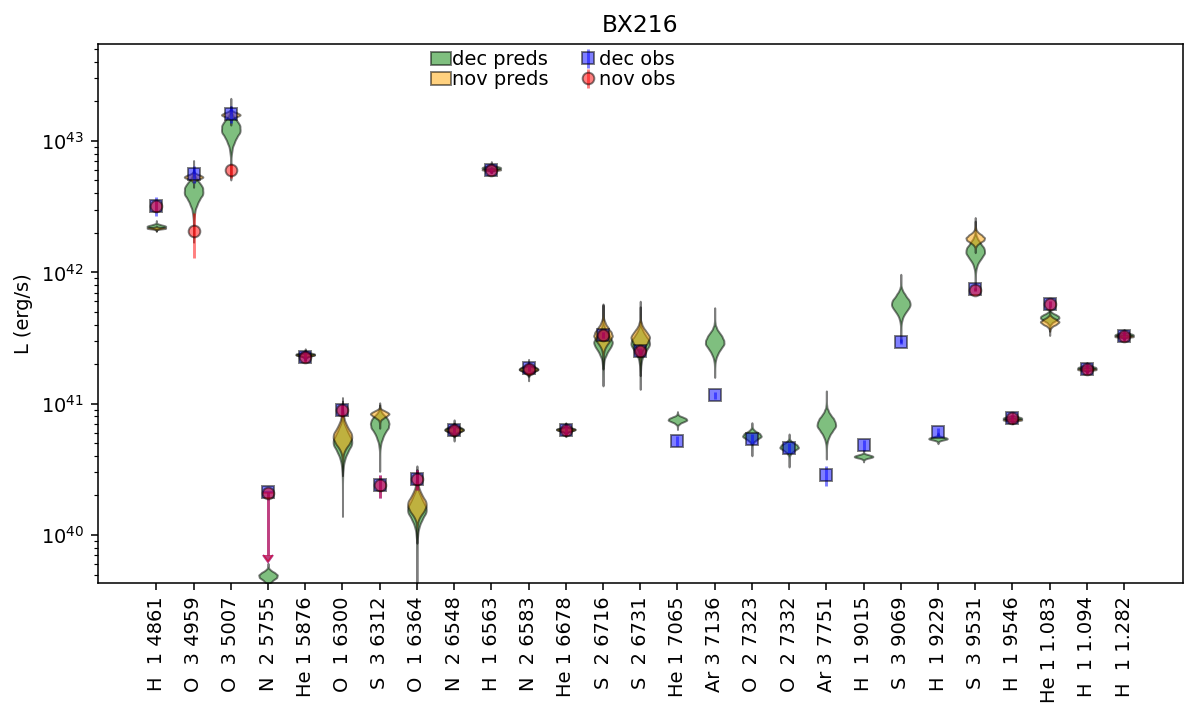

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'H  1 9014.91A' 'H  1 9229.02A'
 'He 1 7065.25A' 'O  2 7323.00A' 'O  2 7332.00A' 'S  3 9068.62A']


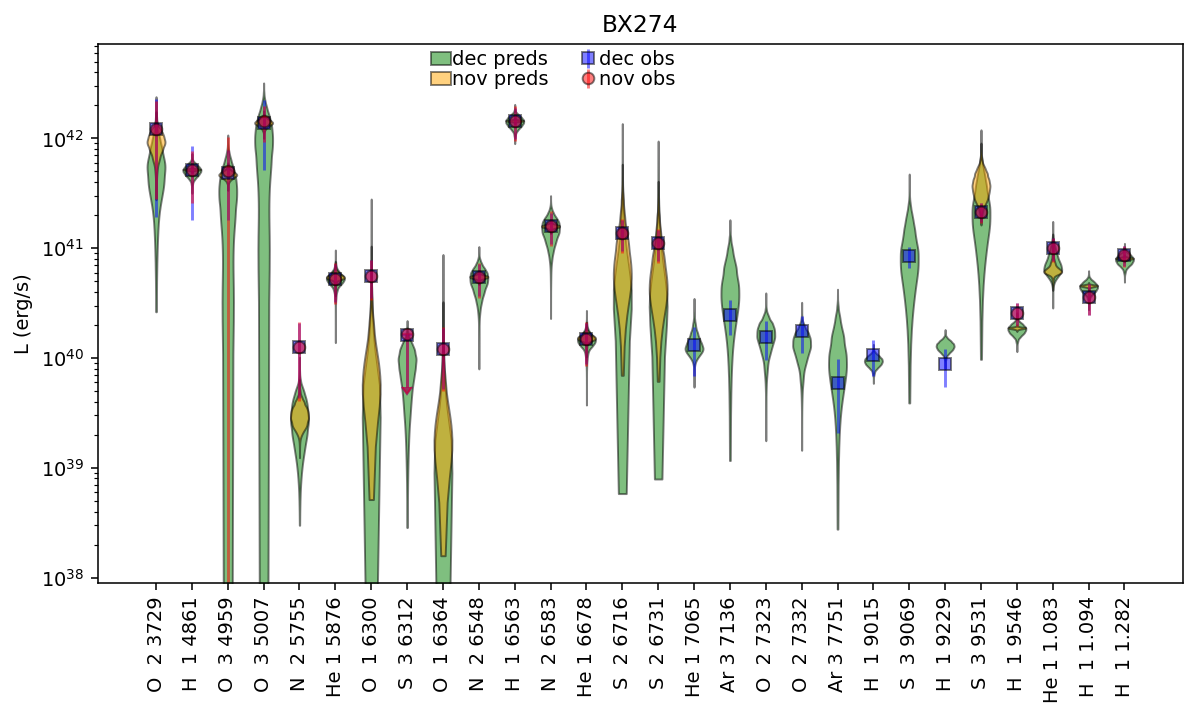

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


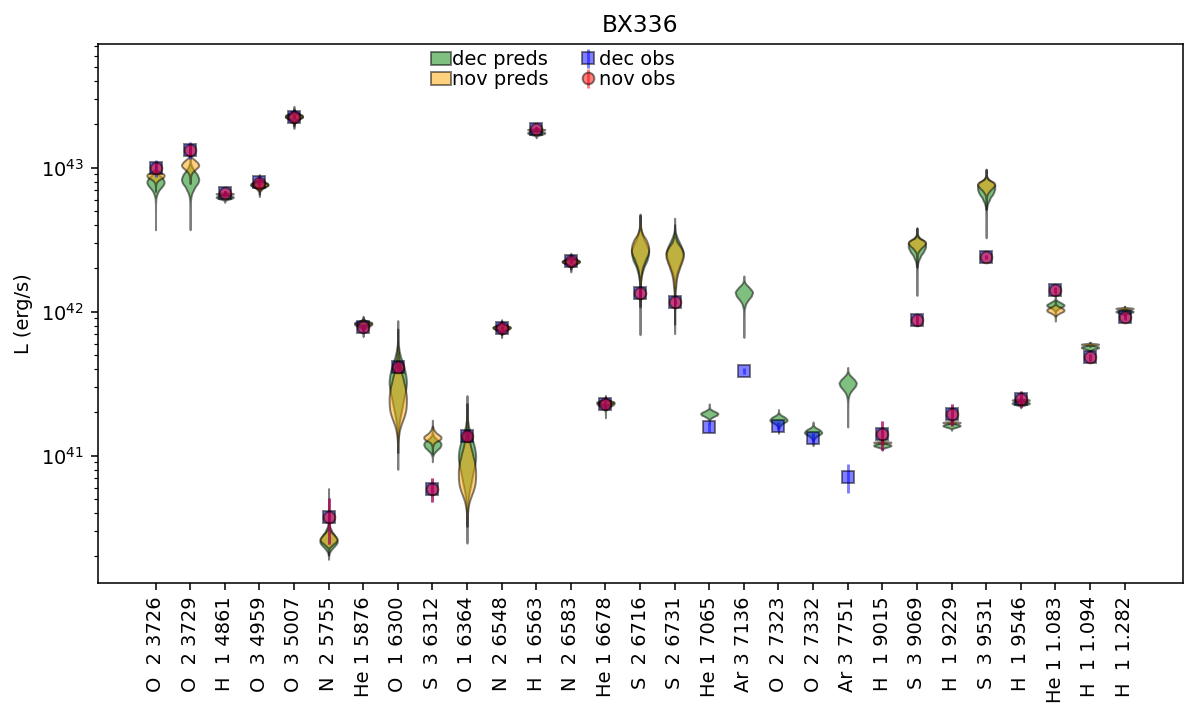

['Ar 3 7135.79A' 'He 1 7065.25A' 'O  2 7323.00A' 'O  2 7332.00A']


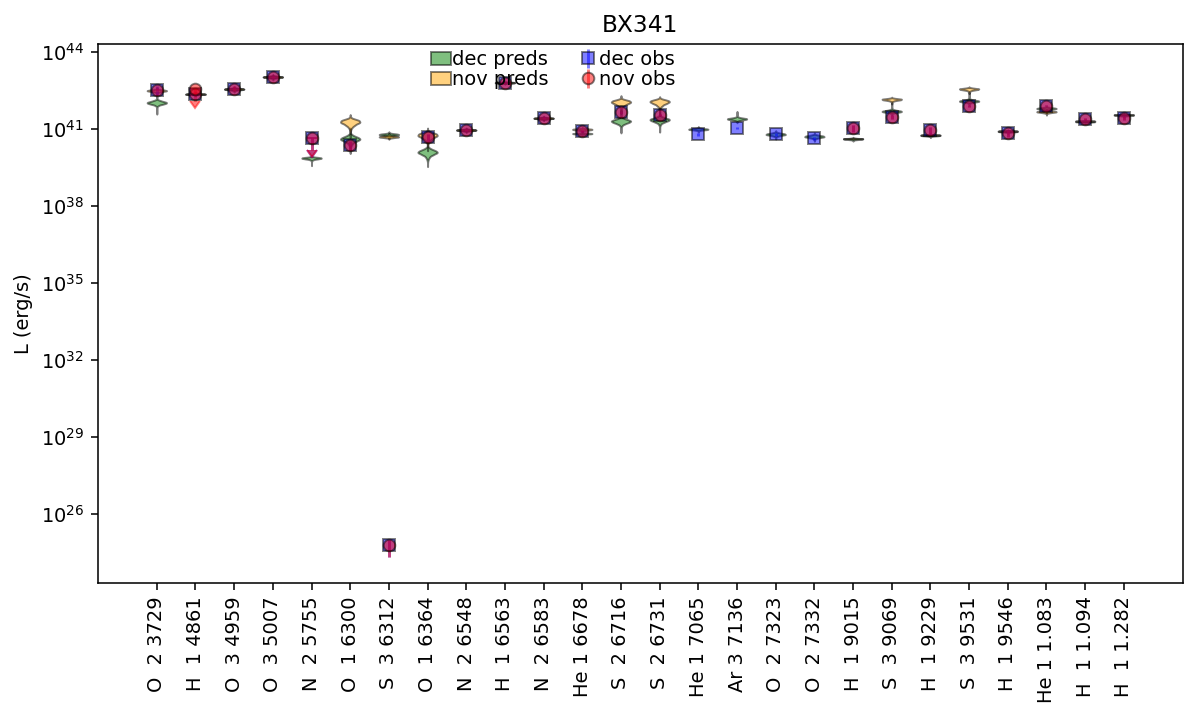

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


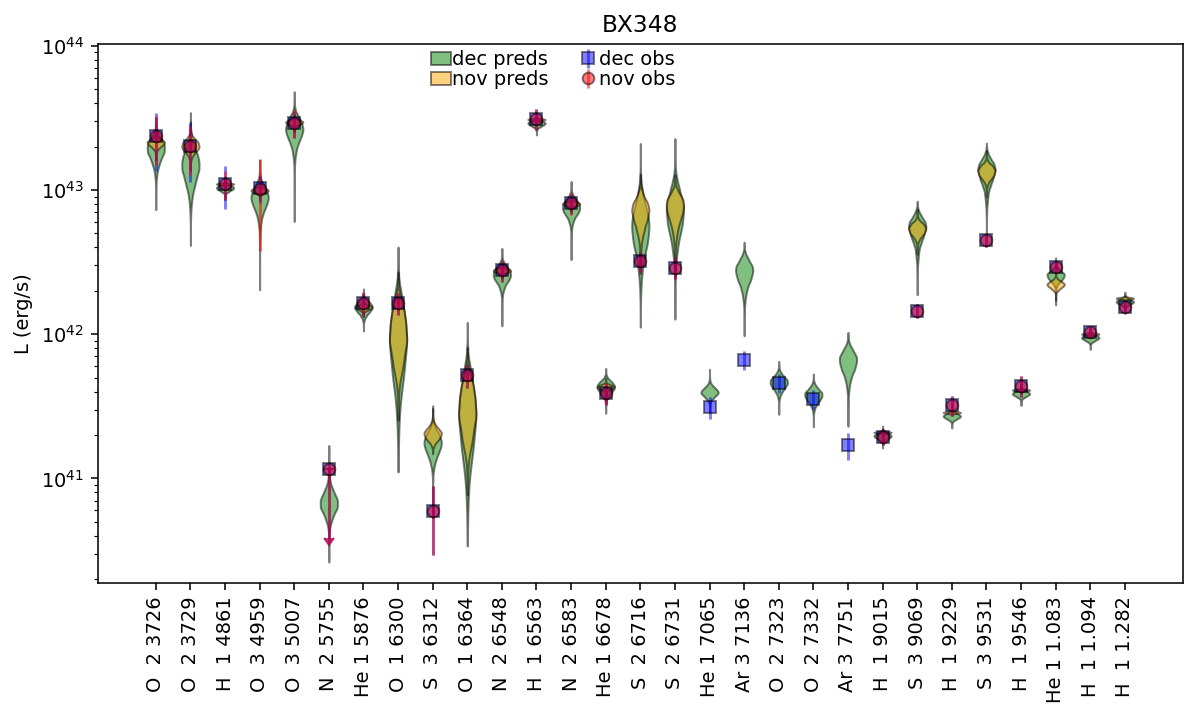

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


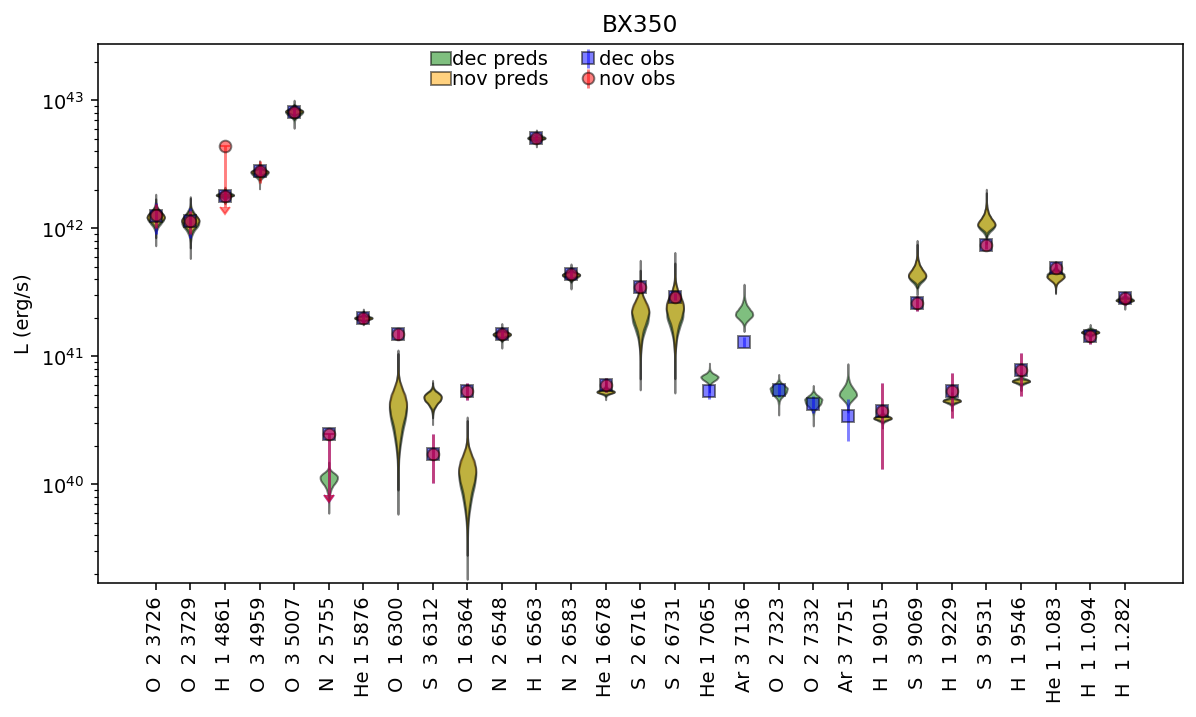

['Ar 3 7751.11A']


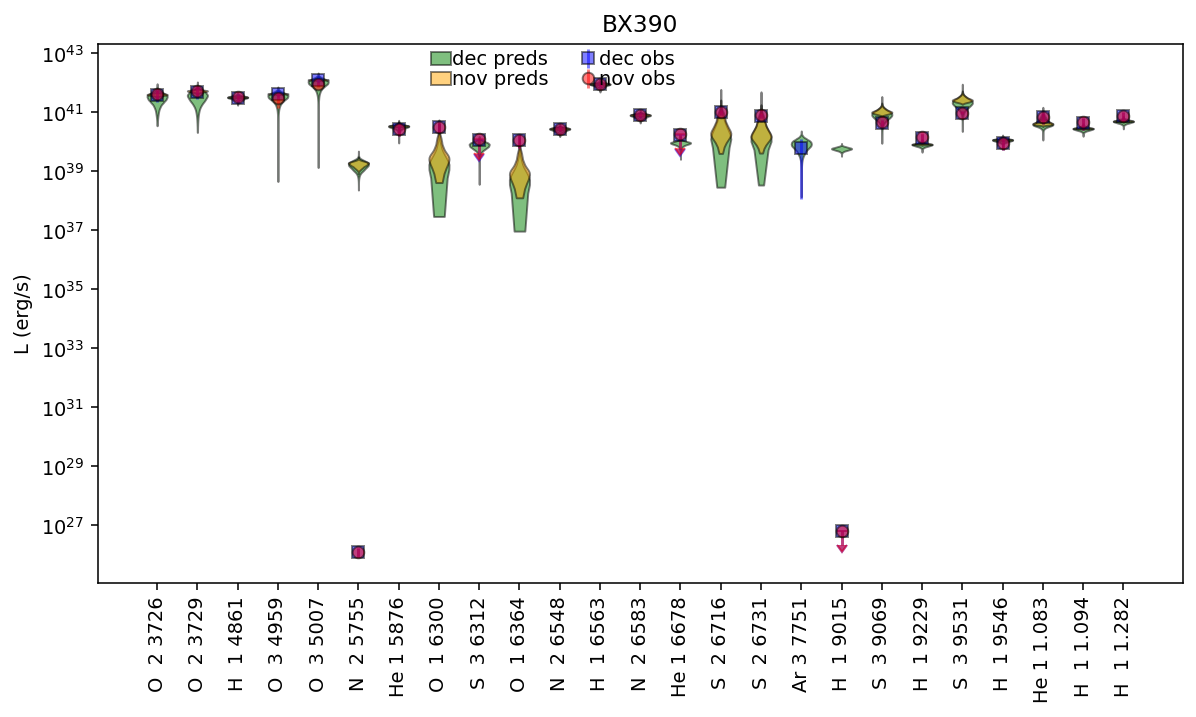

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


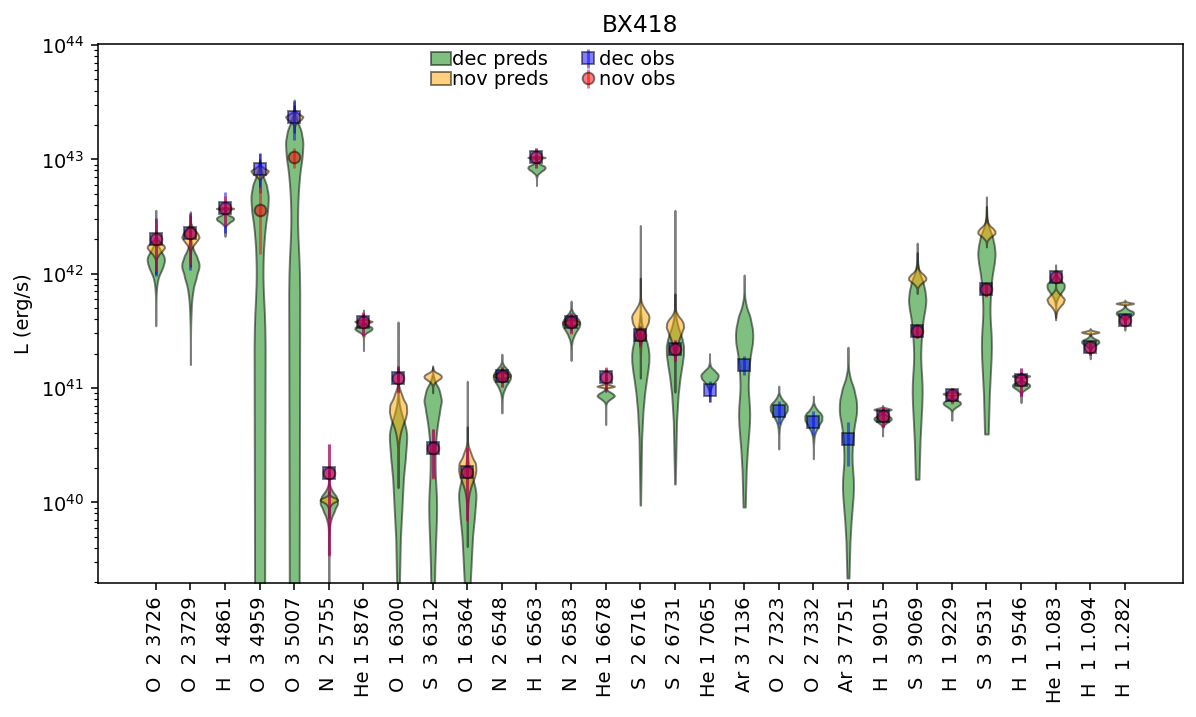

['Ar 3 7751.11A' 'H  1 9014.91A' 'S  3 9068.62A']


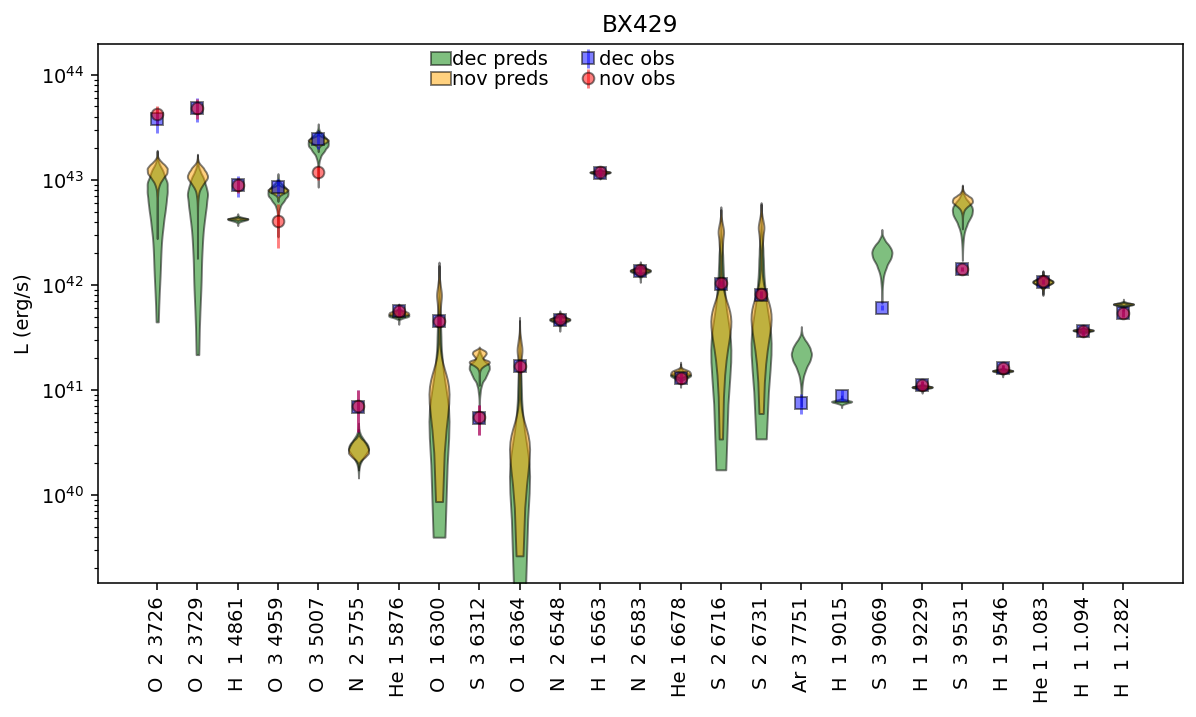

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


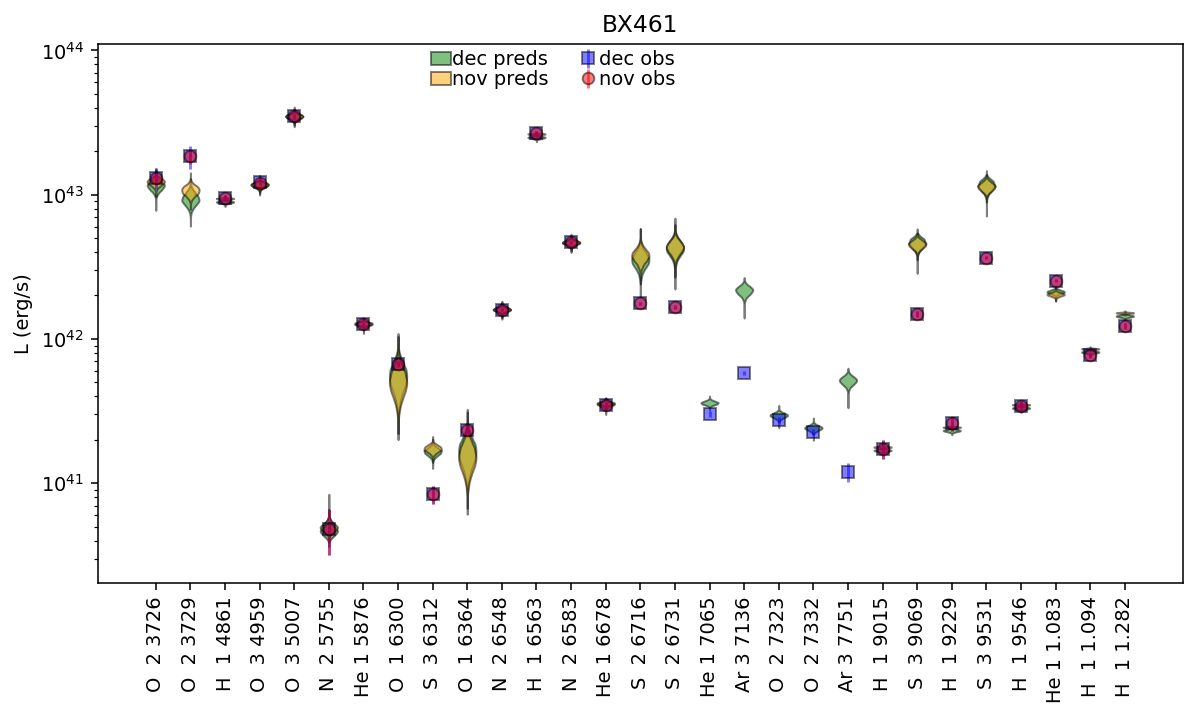

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


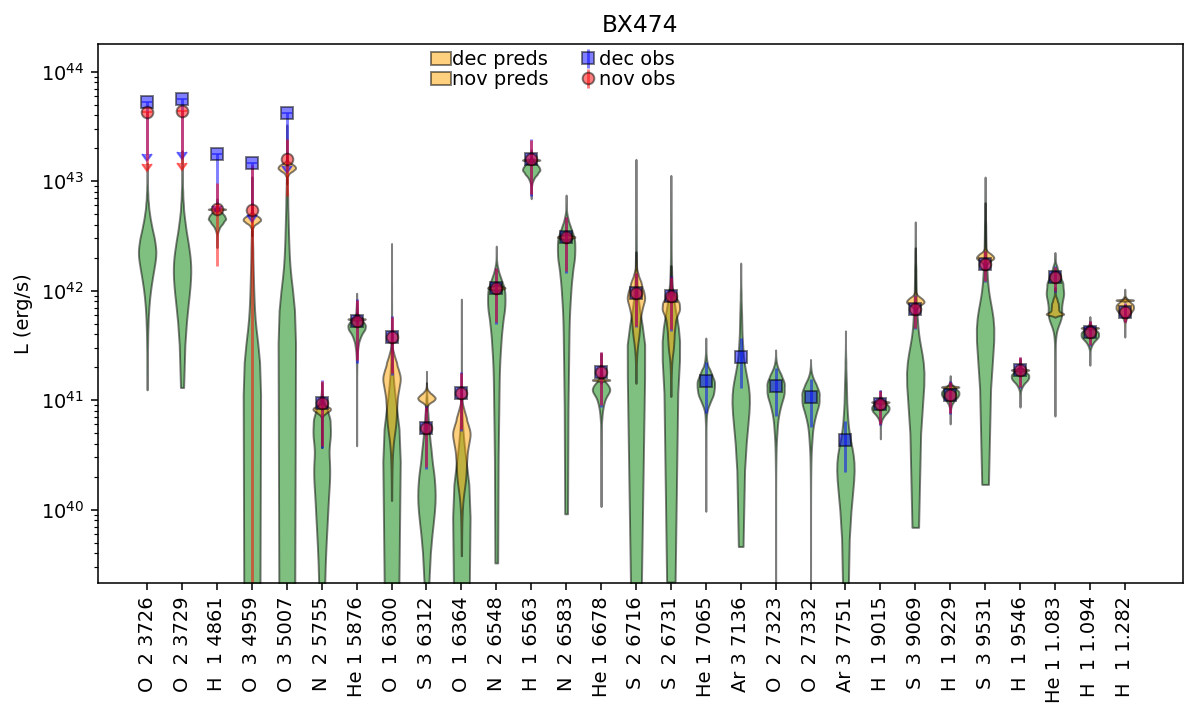

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


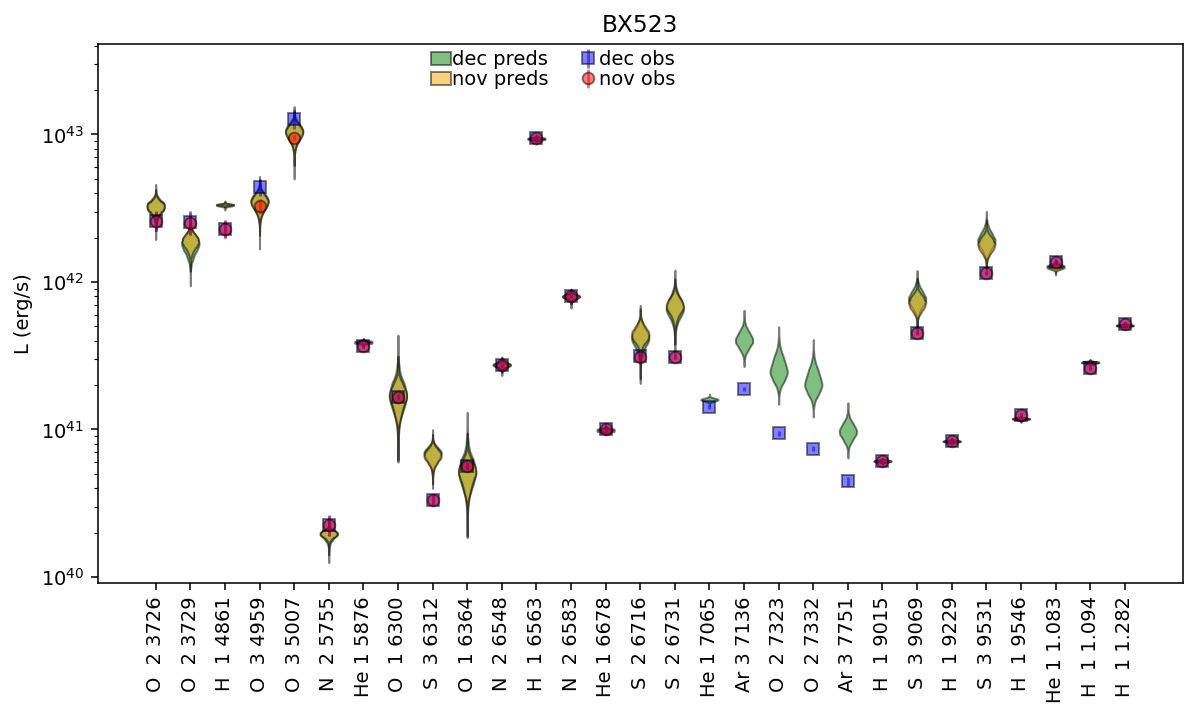

['Ar 3 7135.79A' 'He 1 7065.25A' 'O  2 7323.00A' 'O  2 7332.00A']


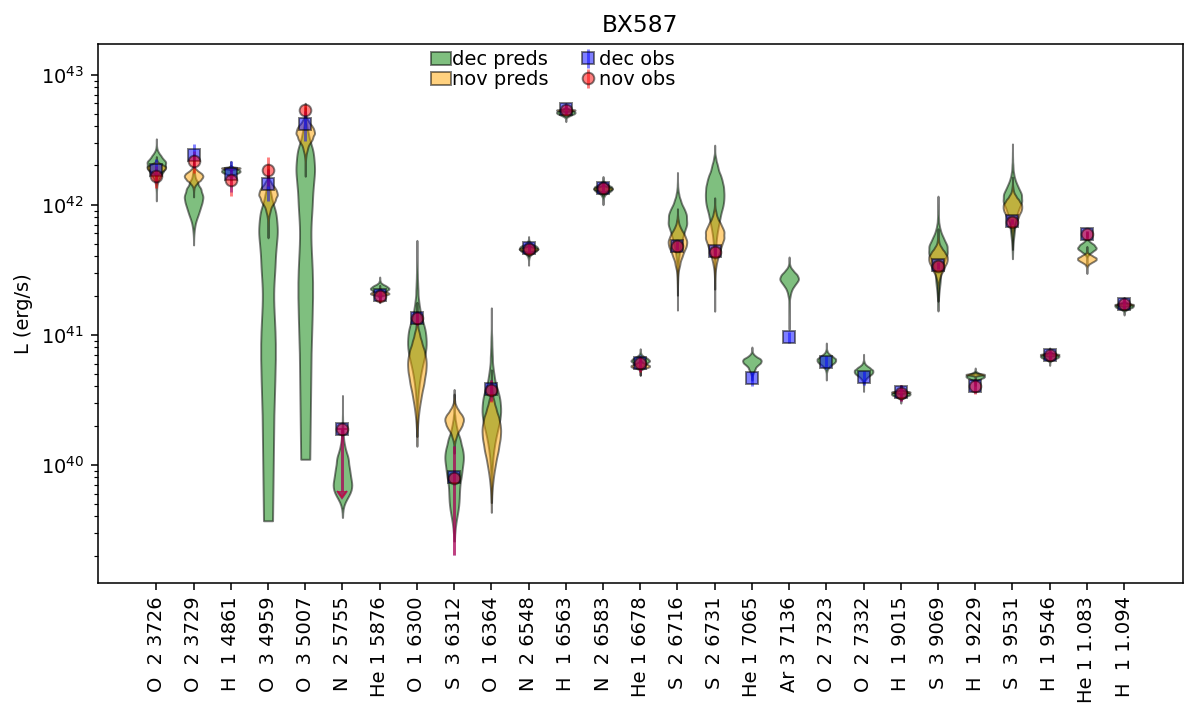

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


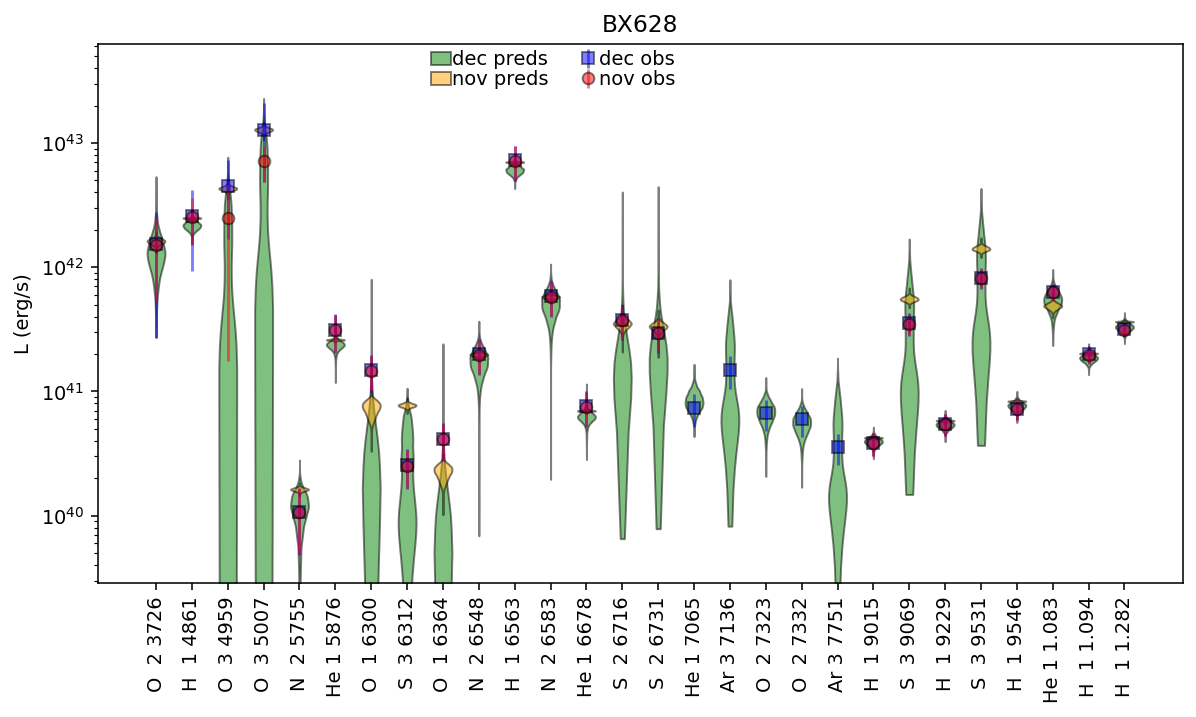

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


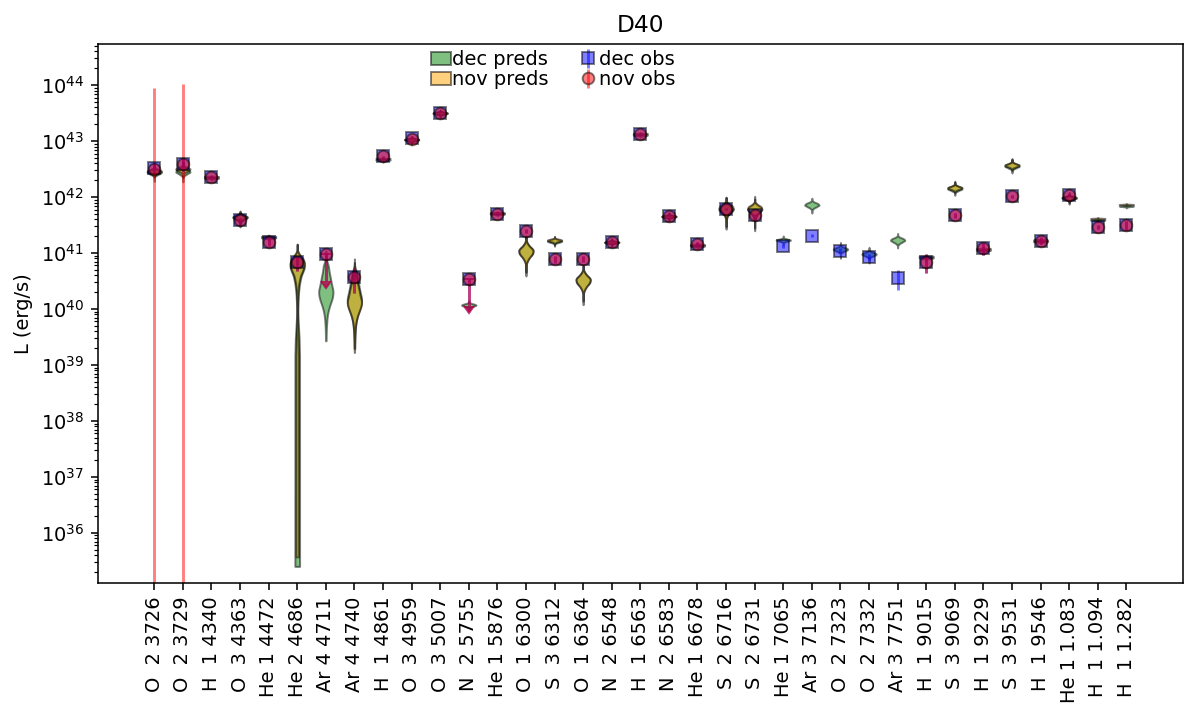

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'H  1 9014.91A' 'He 1 7065.25A'
 'O  2 7323.00A' 'O  2 7332.00A' 'S  3 9068.62A']


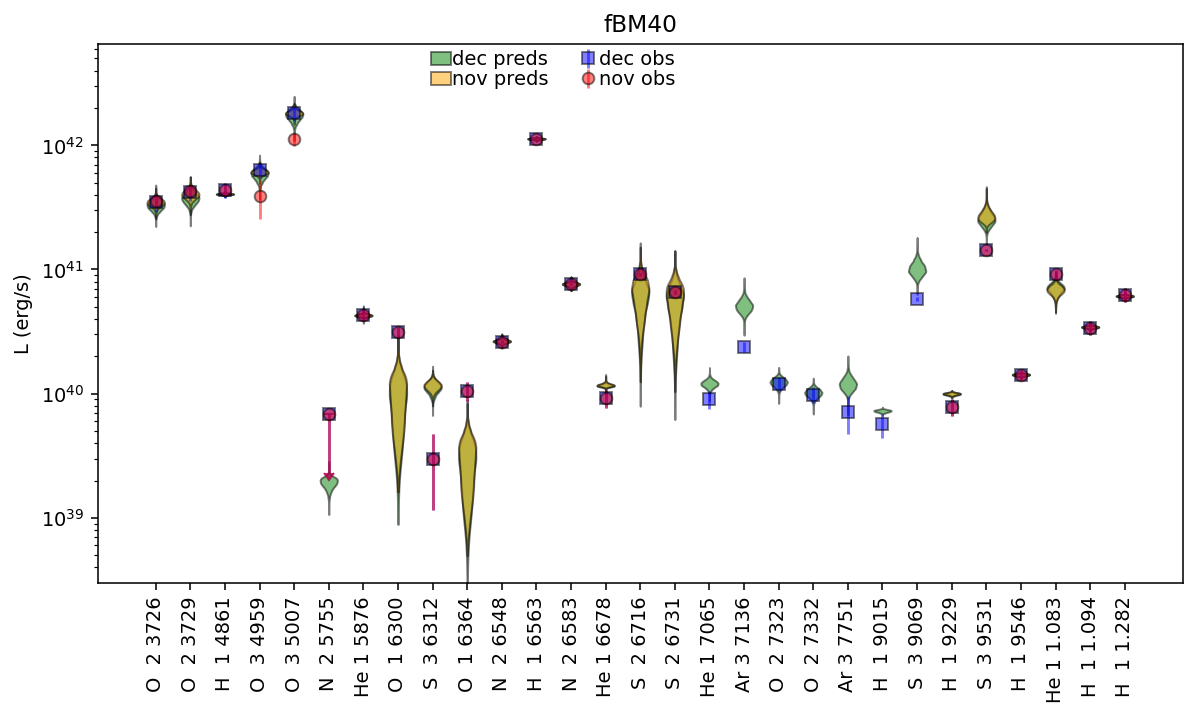

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'He 1 7065.25A' 'O  2 7323.00A'
 'O  2 7332.00A']


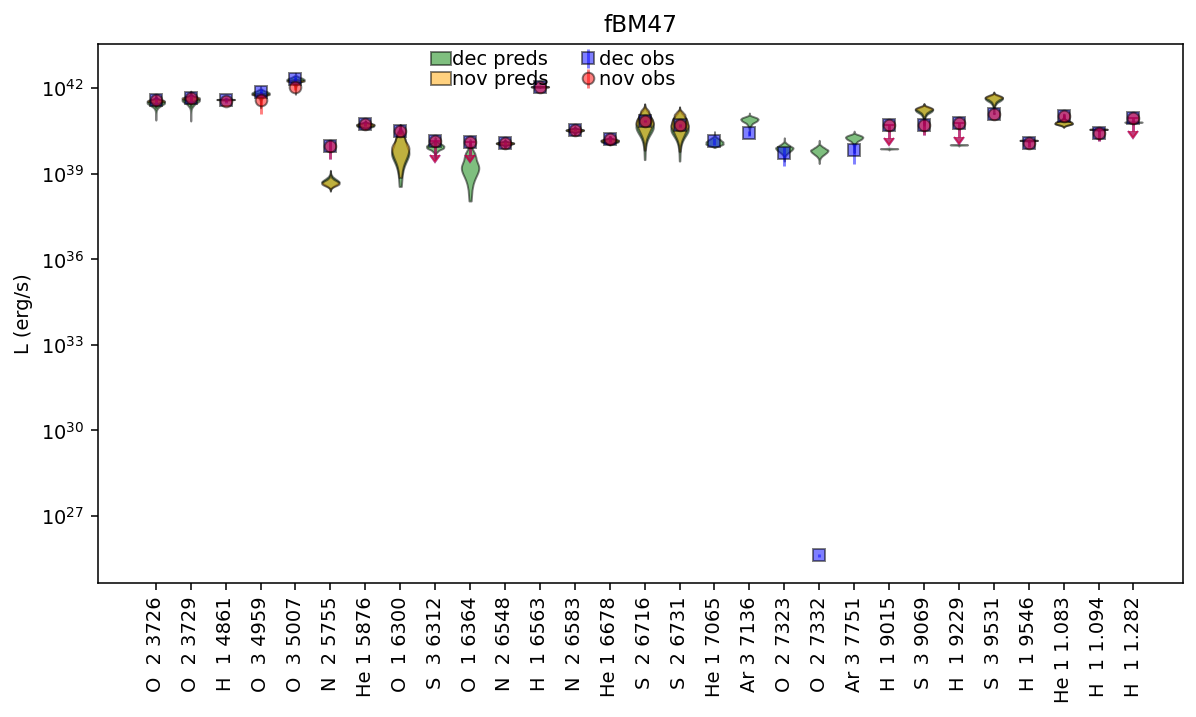

['Ar 3 7135.79A' 'Ar 3 7751.11A' 'H  1 9014.91A' 'He 1 7065.25A'
 'O  2 7323.00A' 'O  2 7332.00A' 'S  3 9068.62A']


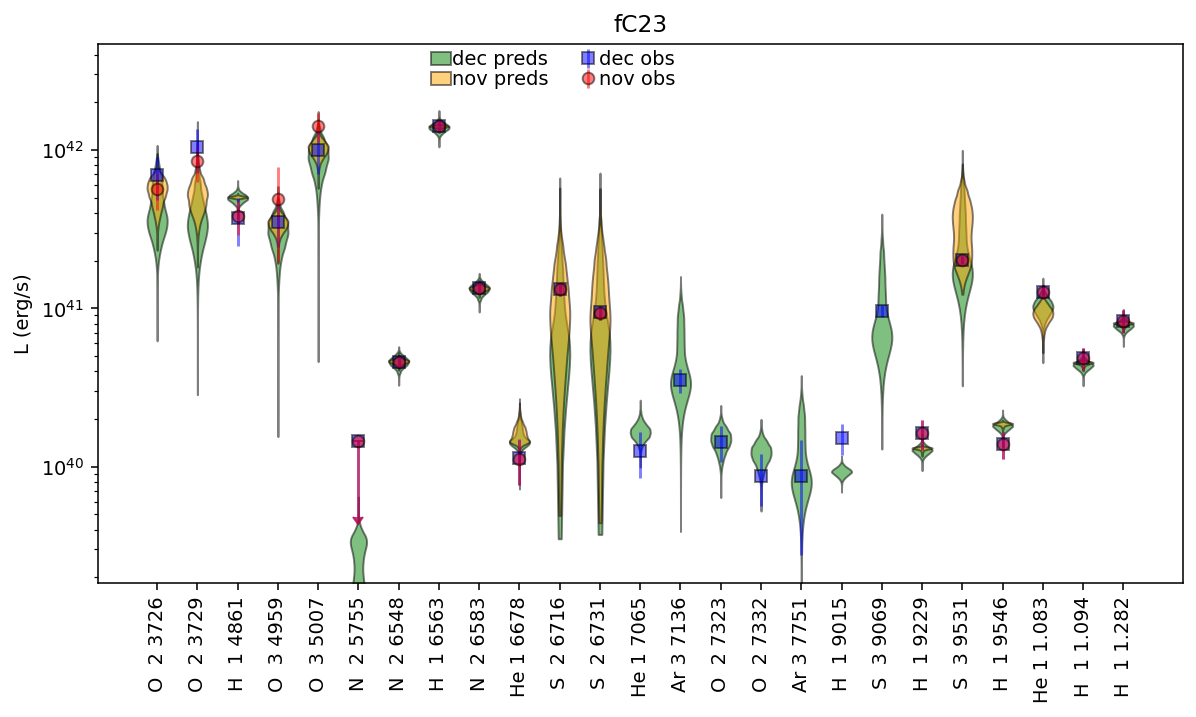

In [18]:
for galaxy in galaxynames:
    nov_obsfile = "/home/carolinevr/cue/cecilia-runs/galaxy-observational-data/line_luminosities/"+galaxy+"_fluxSN.pkl"
    nov_results_file = "/home/carolinevr/cue/cecilia-runs/cue-results/correct-ionizing-spec-priors/"+galaxy+"_results_nolowion_noarsulf_fluxSN_stellar.pkl"
    nov_preds_file = "/home/carolinevr/cue/cecilia-runs/line-predictions/correct-ionizing-spec-priors/"+galaxy+".pkl"

    dec_obsfile = "/home/carolinevr/cue/cecilia-runs/galaxy-observational-data/line_luminosities_dec/"+galaxy+".pkl"
    dec_results_file = "/home/carolinevr/cue/cecilia-runs/final-run-stellar-prior/"+galaxy+"_results_nolowion_noarsulf.pkl"
    dec_preds_file = "/home/carolinevr/cue/cecilia-runs/final-run-stellar-prior/"+galaxy+"_preds_nolowion_noarsulf.pkl"

    with open(dec_obsfile, 'rb') as f:
        decobs = pickle.load(f)
    with open(nov_obsfile, 'rb') as f:
        novobs = pickle.load(f)
    with open(dec_preds_file, 'rb') as f:
        decpreds = pickle.load(f)
    with open(nov_preds_file, 'rb') as f:
        novpreds = pickle.load(f)
    with open(dec_results_file, 'rb') as f:
        decresults = pickle.load(f)
    with open(nov_results_file, 'rb') as f:
        novresults = pickle.load(f)


    dec_obslines, = np.where((decobs['line_lum']!=0) | (decobs['line_lum_up']!=0))
    nov_obslines, = np.where((novobs['line_lum']!=0) | (novobs['line_lum_up']!=0))
    diff_lines = np.setdiff1d(np.array(decobs['line_name'][dec_obslines]), np.array(novobs['line_name'][nov_obslines]))
    print(diff_lines)

    decwav_ind, = np.where((decobs['line_lum']!=0) | (decobs['line_lum_up']!=0))
    decwav_ind_obs, = np.where(decobs['line_lum']!=0)  # indices where line is observed
    decwav_ind_up, = np.where(decobs['line_lum_up']!=0)

    fig, (ax) = plt.subplots(1, 1, #sharex=True, 
                                            gridspec_kw={'height_ratios': [3],
                                                        'hspace': 0.},
                                            figsize=(10,5.), dpi=140)

    plt.title(galaxy)

    "violin plot for predictions"
    for pt in range(len(decwav_ind)):
        viplot = ax.violinplot(np.array(decpreds)[:,decwav_ind[pt]], positions = [pt], showmeans=False, showmedians=False, showextrema=False, orientation="vertical")

        for piece in viplot["bodies"]:
            piece.set_facecolor("green")
            piece.set_edgecolor("black")
            piece.set_alpha(0.5)
    viplot['bodies'][-1].set_label("dec preds")

    for ind in decwav_ind:
        if ind in decwav_ind_obs:
            if ind == decwav_ind_obs[0]:
                ax.errorbar(shortened_sorted_line_name[ind], decobs["line_lum"][ind], yerr=decobs["line_lum_unc"][ind],
                marker="s", ls=' ', color="blue", markeredgecolor='k', alpha=0.5,
                label="dec obs")
            else:
                ax.errorbar(shortened_sorted_line_name[ind], decobs["line_lum"][ind], yerr=decobs["line_lum_unc"][ind],
                marker="s", ls=' ', color="blue", markeredgecolor='k', alpha=0.5)
        if ind in decwav_ind_up:
            ax.errorbar(shortened_sorted_line_name[ind], decobs["line_lum_up"][ind], yerr=decobs["line_lum_up"][ind]/1.5,
                marker="s", ls=' ', uplims=True, color="blue", markeredgecolor='k', alpha=0.5, capsize=2.5)
            

    novwav_ind, = np.where((novobs['line_lum']!=0) | (novobs['line_lum_up']!=0))
    novwav_ind_obs, = np.where(novobs['line_lum']!=0)  # indices where line is observed
    novwav_ind_up, = np.where(novobs['line_lum_up']!=0)

    "violin plot for predictions"
    for pt in range(len(decwav_ind)):
        if decwav_ind[pt] in novwav_ind_obs:
            viplot = ax.violinplot(np.array(novpreds)[:,decwav_ind[pt]], positions = [pt], showmeans=False, showmedians=False, showextrema=False, orientation="vertical")



        for piece in viplot["bodies"]:
            piece.set_facecolor("orange")
            piece.set_edgecolor("black")
            piece.set_alpha(0.5)
    viplot['bodies'][-1].set_label("nov preds")

    for ind in decwav_ind:
        if ind in novwav_ind_obs:
            if ind == novwav_ind_obs[0]:
                ax.errorbar(shortened_sorted_line_name[ind], novobs["line_lum"][ind], yerr=novobs["line_lum_unc"][ind],
                marker="o", ls=' ', color="red", markeredgecolor='k', alpha=0.5,
                label="nov obs")
            else:
                ax.errorbar(shortened_sorted_line_name[ind], novobs["line_lum"][ind], yerr=novobs["line_lum_unc"][ind],
                marker="o", ls=' ', color="red", markeredgecolor='k', alpha=0.5)
        if ind in novwav_ind_up:
            ax.errorbar(shortened_sorted_line_name[ind], novobs["line_lum_up"][ind], yerr=novobs["line_lum_up"][ind]/1.5,
                marker="o", ls=' ', uplims=True, color="red", markeredgecolor='k', alpha=0.5, capsize=2.5)
        elif ind not in novwav_ind:
            ax.errorbar(shortened_sorted_line_name[ind], 0, 
                marker="o", ls=' ', color="red", markeredgecolor='k', alpha=0.5)


    ax.legend(framealpha=0., handletextpad=0.08, labelspacing=0.05, 
                    ncol=2, columnspacing=1.5, handlelength=1.0, 
                    loc='upper center', bbox_to_anchor=(0.42, 1.02)); 
    ax.set_ylabel(r'L (erg/s)')
    ax.set_yscale('log')
    # ax.set_xticklabels(shortened_sorted_line_name[decwav_ind])
    ax.set_ylim(ax.get_ylim()[0]*0.92, ax.get_ylim()[1]*2)
    # ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(numticks=999, subs="auto"))
    # ax.tick_params(axis="x", labelbottom=True)

    plt.xticks(rotation=90);

    plt.show()
